In [1]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [42]:
import os
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt

from langchain_openai import ChatOpenAI
from langchain_core.prompts import PromptTemplate
from langchain_experimental.agents.agent_toolkits import create_pandas_dataframe_agent

from dotenv import load_dotenv
load_dotenv()
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")  
os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY

import warnings
warnings.filterwarnings('ignore')

Matplotlib is building the font cache; this may take a moment.


In [14]:
chat_client = ChatOpenAI(
    model="gpt-4o-mini",
    api_key = OPENAI_API_KEY,
    temperature=0
)

In [ ]:
# ## Testing

# response = chat_client.invoke("Tell me a fun fact about AI.")
# print(response.content)

A fun fact about AI is that the term "artificial intelligence" was first coined in 1956 during a summer workshop at Dartmouth College. The event, organized by John McCarthy, Marvin Minsky, Nathaniel Rochester, and Claude Shannon, is considered the birth of AI as a field of study. Interestingly, the workshop aimed to explore the idea that machines could simulate human intelligence, and it attracted some of the brightest minds in computer science, laying the groundwork for decades of research and development in AI!


In [ ]:
# df = pd.read_csv("Data/provider.csv")
# df.head()

,Rndrng_NPI,Rndrng_Prvdr_Last_Org_Name,Rndrng_Prvdr_First_Name,Rndrng_Prvdr_MI,Rndrng_Prvdr_Crdntls,Rndrng_Prvdr_Ent_Cd,Rndrng_Prvdr_St1,Rndrng_Prvdr_St2,Rndrng_Prvdr_City,Rndrng_Prvdr_State_Abrvtn,...,Bene_CC_PH_Diabetes_V2_Pct,Bene_CC_PH_HF_NonIHD_V2_Pct,Bene_CC_PH_Hyperlipidemia_V2_Pct,Bene_CC_PH_Hypertension_V2_Pct,Bene_CC_PH_IschemicHeart_V2_Pct,Bene_CC_PH_Osteoporosis_V2_Pct,Bene_CC_PH_Parkinson_V2_Pct,Bene_CC_PH_Arthritis_V2_Pct,Bene_CC_PH_Stroke_TIA_V2_Pct,Bene_Avg_Risk_Scre
0,1003000126,Enkeshafi,Ardalan,NaN,M.D.,I,6410 Rockledge Dr Ste 304,NaN,Bethesda,MD,...,45.0,53.0,75.0,75.0,51.0,19.0,4.0,62.0,26.0,2.7545
1,1003000134,Cibull,Thomas,L,M.D.,I,2650 Ridge Ave,Evanston Hospital,Evanston,IL,...,22.0,13.0,75.0,63.0,22.0,19.0,2.0,44.0,6.0,1.1423
2,1003000142,Khalil,Rashid,NaN,M.D.,I,4126 N Holland Sylvania Rd,Suite 220,Toledo,OH,...,44.0,24.0,74.0,75.0,30.0,10.0,NaN,75.0,9.0,1.6448
3,1003000423,Velotta,Jennifer,A,M.D.,I,11100 Euclid Ave,NaN,Cleveland,OH,...,22.0,NaN,75.0,59.0,19.0,22.0,NaN,57.0,NaN,0.7370
4,1003000480,Rothchild,Kevin,B,MD,I,12605 E 16th Ave,NaN,Aurora,CO,...,33.0,16.0,69.0,74.0,27.0,15.0,NaN,63.0,NaN,1.7264


In [ ]:
# metadata = {
#     "provider": "The dataset contains provider-level billing and reimbursement details for specific services or procedures, capturing service frequency, billed amounts, and payments for comparative analysis across providers and service types.",
#     "claims": "The dataset contains historical insurance claim records with policyholder demographics, claim history, and related features designed for predictive modeling of future claim likelihood.",
#     "marketing": "The dataset contains information on 2,206 customers of XYZ company, including customer profiles, product preferences, marketing campaign performance, and sales channel effectiveness."
# }

metadata = {
    "provider": "Provider-level Medicare billing dataset. Contains provider info and summary fields such as Tot_Sbmtd_Chrg, Tot_Srvcs, Tot_Mdcr_Pymt_Amt. The dataset contains provider-level billing and reimbursement details for specific services or procedures, capturing service frequency, billed amounts, and payments for comparative analysis across providers and service types.",
    "claims": "Insurance policy + claim status dataset. NOT related to provider charges. Contains vehicle, customer, and claim features. The dataset contains historical insurance claim records with policyholder demographics, claim history, and related features designed for predictive modeling of future claim likelihood. ",
    "marketing": "Customer marketing dataset. NOT related to provider charges. The dataset contains information on 2,206 customers of XYZ company, including customer profiles, product preferences, marketing campaign performance, and sales channel effectiveness."
}

In [18]:
data_dir = "Data"
datasets = {}

for file in os.listdir(data_dir):
    if file.endswith(".csv"):
        name = file.replace(".csv", "")
        datasets[name] = pd.read_csv(os.path.join(data_dir, file))

In [19]:
datasets.keys()

dict_keys(['claims', 'marketing', 'provider'])

In [20]:
dataset_selector_prompt = PromptTemplate(
    input_variables=["query", "metadata"],
    template=(
        "You are a data reasoning assistant. You have access to the following datasets:\n\n"
        "{metadata}\n\n"
        "Given the user query:\n'{query}'\n\n"
        "Which datasets are needed to answer this? "
        "Return a comma-separated list of dataset names only (no explanations)."
    )
)

In [23]:
def select_datasets(chat_client, query, metadata):
    metadata_text = "\n".join([f"{k}: {v}" for k, v in metadata.items()])
    formatted_prompt = dataset_selector_prompt.format(query=query, metadata=metadata_text)
    response = chat_client.invoke(formatted_prompt)
    selected = [ds.strip() for ds in response.content.split(",") if ds.strip() in metadata.keys()]
    return selected

In [24]:
query = "Which provider is charging more over the past 3 months?"

selected = select_datasets(chat_client, query, metadata)
print("Datasets selected:", selected)

dfs = [datasets[name] for name in selected]
if len(dfs) > 1:
    combined_df = pd.concat(dfs, axis=1, join="inner")
else:
    combined_df = dfs[0]

Datasets selected: ['provider']


In [43]:
agent = create_pandas_dataframe_agent(
    llm=chat_client,
    df=combined_df,
    verbose=True,
    allow_dangerous_code=True,  # REQUIRED for plotting!
    agent_type="tool-calling"
)



In [ ]:
graph_generator_prompt = PromptTemplate(
    input_variables=["query", "metadata"],
    template=("""You are a data visualization expert.
              
              You have access to the following datasets:\n\n"
        "{metadata}\n\n"
        "Given the user query:\n'{query}'\n\n"
              
     Based on the query select datasets are needed to plot.         
Given a user query and a dataframe:

1. Determine the analytical intent of the query.
2. Decide whether the best answer is:
   - a comparison, 
   - a distribution,
   - a trend,
   - or a ranking.

3. Select the most appropriate visualization:
   - Bar chart for ranking or comparison.
   - Line plot for trends over time.
   - Histogram for distribution.
   - Scatter plot for relationships.

4. ALWAYS produce a graph as part of your answer.
5. NEVER ask the user which graph to use.
6. NEVER require explicit commands like 'plot', 'graph', 'bar chart'.

Return only the graph relevant to the query
"""))

def graph_agent(chat_client, query, metadata):
    metadata_text = "\n".join([f"{k}: {v}" for k, v in metadata.items()])
    formatted_prompt = graph_generator_prompt.format(query=query, metadata=metadata_text)
    response = chat_client.invoke(formatted_prompt)
    selected = [ds.strip() for ds in response.content.split(",") if ds.strip() in metadata.keys()]
    return selected



> Entering new AgentExecutor chain...

Invoking: `python_repl_ast` with `{'query': "import pandas as pd\nimport matplotlib.pyplot as plt\n\n# Assuming df is already defined as the DataFrame\n# Sort the DataFrame by 'Tot_Sbmtd_Chrg' in descending order and get the top 10 providers\ntop_providers = df.nlargest(10, 'Tot_Sbmtd_Chrg')\n\n# Create a bar chart\nplt.figure(figsize=(12, 6))\nplt.bar(top_providers['Rndrng_NPI'].astype(str), top_providers['Tot_Sbmtd_Chrg'], color='skyblue')\nplt.xlabel('Provider NPI')\nplt.ylabel('Total Submitted Charges')\nplt.title('Top 10 Providers with Highest Total Submitted Charges')\nplt.xticks(rotation=45)\nplt.tight_layout()\nplt.show()"}`




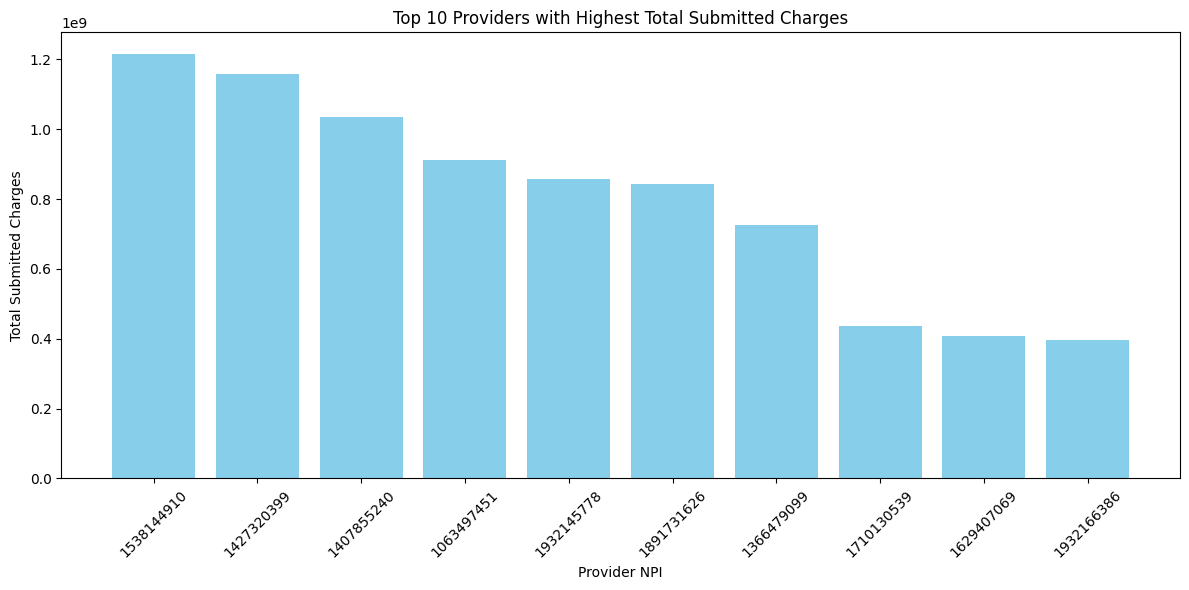

The bar chart displaying the top 10 providers with the highest total submitted charges has been generated successfully. The x-axis represents the provider NPI, while the y-axis shows the total submitted charges. If you have any further questions or need additional analysis, feel free to ask!

> Finished chain.


In [ ]:
# query = """
# Who are the top 10 providers with the highest total submitted charges.
# """
# response = agent.invoke(query)

    response = agent.invoke("""
    Plot the top 10 providers with the highest total submitted charges.
    Use a bar chart with provider NPI on x-axis and Tot_Sbmtd_Chrg on y-axis.
    """)

In [49]:
graph_prompt = """
You are a data visualization expert.

Given a user query and a dataframe:

1. Determine the analytical intent of the query.
2. Decide whether the best answer is:
   - a comparison, 
   - a distribution,
   - a trend,
   - or a ranking.

3. Select the most appropriate visualization:
   - Bar chart for ranking or comparison.
   - Line plot for trends over time.
   - Histogram for distribution.
   - Scatter plot for relationships.

4. ALWAYS produce a graph as part of your answer.
5. NEVER ask the user which graph to use.
6. NEVER require explicit commands like 'plot', 'graph', 'bar chart'.

Return only Python code that:
- performs the correct computation
- generates the appropriate matplotlib graph
- labels axes and title clearly
- displays the plot

Use the dataframe variable name: df
"""


In [52]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import HumanMessage
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI




In [66]:
def get_schema_string(df):
    cols = df.columns.tolist()
    return "The dataframe has the following columns:\n" + "\n".join(f"- {c}" for c in cols)

import textwrap

import re

@tool
def python_plotter(code: str):
    """
    Execute Python code that works on a dataframe named df.
    Cleans all indentation problems automatically.
    """

    global df

    # 1. Remove surrounding whitespace
    cleaned = code.strip()

    # 2. Remove ANY leading whitespace from every line
    cleaned = "\n".join(line.lstrip() for line in cleaned.splitlines())

    # 3. Dedent AGAIN (safety)
    cleaned = textwrap.dedent(cleaned)

    print("Executing cleaned code:\n", cleaned)

    try:
        exec(cleaned, globals())
    except Exception as e:
        print("ERROR executing code:")
        print(cleaned)
        raise e




In [67]:
def build_graph_prompt(df, user_query):
    schema = get_schema_string(df)

    return f"""
You are a data visualization expert.

You MUST obey these rules:
1. ONLY use column names that exist in the dataframe.
2. Here is the schema of the dataframe:

{schema}

3. Infer the analytic intent:
   - Ranking → bar chart
   - Comparison → bar chart
   - Trend → line chart
   - Distribution → histogram
   - Relationship → scatter plot

4. ALWAYS return valid Python code that:
   - Uses the dataframe variable 'df'
   - Computes the analysis
   - Chooses the correct chart automatically
   - Generates a matplotlib plot
   - Labels axes and titles clearly

5. DO NOT ask the user any questions.
6. DO NOT include explanations — return ONLY Python code.

User query: {user_query}
"""


In [68]:
def answer_with_graph(query):
    # Step 1: dataset selector
    selected = select_datasets(chat_client, query, metadata)
    df = datasets[selected[0]]
    globals()["df"] = df

    # Step 2: build prompt that includes schema
    full_prompt = build_graph_prompt(df, query)

    messages = [
        ("system", full_prompt),
        ("human", query)
    ]

    # Step 3: agent inference
    response = graph_agent.invoke(messages)

    # Step 4: execute python tool call
    if hasattr(response, "tool_calls") and response.tool_calls:
        for call in response.tool_calls:
            if call["name"] == "python_plotter":
                return python_plotter.invoke(call["args"]["code"])

    return response.content


Executing cleaned code:
 import matplotlib.pyplot as plt

# Get the top 10 providers with the highest total submitted charges
top_providers = df.nlargest(10, 'Tot_Sbmtd_Chrg')

# Create a bar chart
plt.figure(figsize=(12, 6))
plt.bar(top_providers['Rndrng_Prvdr_Last_Org_Name'] + ', ' + top_providers['Rndrng_Prvdr_First_Name'], top_providers['Tot_Sbmtd_Chrg'], color='skyblue')
plt.xlabel('Providers')
plt.ylabel('Total Submitted Charges')
plt.title('Top 10 Providers with Highest Total Submitted Charges')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


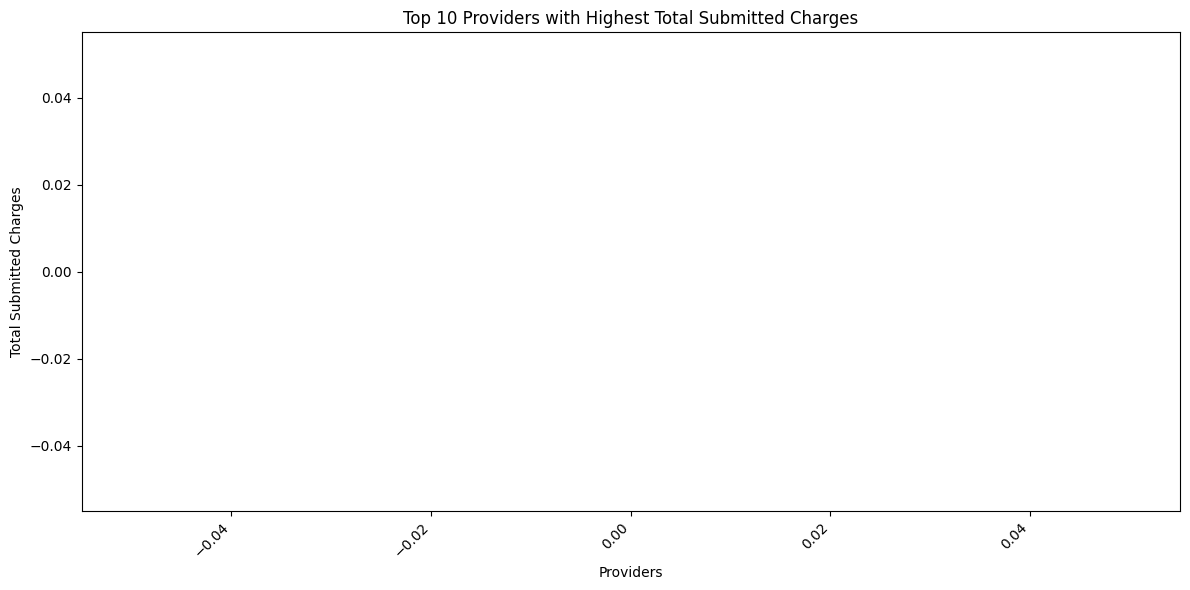

In [ ]:
answer_with_graph("Who are the top 10 providers with the highest total submitted charges ? ")
